In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
class LLaVAMemoryEstimator:
    def __init__(self):
        # LLaVA-1.5-7b
        self.hidden_size = 4096
        self.num_hidden_layers = 32
        self.num_attention_heads = 32
        self.intermediate_size = 11008
        self.vocab_size = 32064
        
        # CLIP ViT-L operates in 336x336
        self.vision_hidden_size = 1024
        self.vision_intermediate = 4096
        self.vision_layers = 24
        self.image_token_count = 576
        
        # fp16 operations assumption
        self.bytes_per_param = 2

    def format_size(self, size_bytes):
            """
            Helper: Returns the size in GB as a raw number (float).
            """
            return size_bytes / (1024 ** 3)

    def estimate(self, batch_size, max_new_tokens, text_input_len=30):
        """
        Estimates VRAM consumption for LLaVA-1.5-7b during inference.
        Args:
            batch_size: Number of inputs in a batch
            max_new_tokens: Number of tokens to be generated

        Returns 
            - Estimated vRAM usage 
            - KV Cache
            - Activation Scratchpad
        """
     
        # LLM Weights
        llm_embeddings = self.vocab_size * self.hidden_size * 2 # References tie word embeddings which is set to False in configuration

        llm_layers = 32 * (
            (4 * self.hidden_size * self.hidden_size) +   # Self attention, for q, k, v, o
            (3 * self.hidden_size * self.intermediate_size) + # SwiGLU MLP -> gate, up, down projections
            (2 * self.hidden_size) # LayerNorm for input and post attention
        )

        llm_params = llm_embeddings + llm_layers + self.hidden_size
        
        # CLIP ViT-Large
        vision_params = 304_000_000 

        # MLP Projector to map image tokens to text embedding space
        projector_params = (self.vision_hidden_size * self.hidden_size) + (self.hidden_size * self.hidden_size)

        # net weights
        total_params = llm_params + vision_params + projector_params
        model_weights_mem = total_params * self.bytes_per_param

        # prefill section, generate initial KV Cache
        total_input_tokens = text_input_len + self.image_token_count #text+image tokens
        total_seq_len = total_input_tokens + max_new_tokens
        activation_scratchpad = (batch_size * total_input_tokens * self.intermediate_size * self.bytes_per_param)  # estimate size of activation from prefill section

        # subsequent kv cache generation
        kv_cache_mem = (2 * self.num_hidden_layers * self.hidden_size * batch_size * total_seq_len * self.bytes_per_param)

        total_allocated = model_weights_mem + kv_cache_mem + activation_scratchpad

        return self.format_size(total_allocated), self.format_size(kv_cache_mem), self.format_size(activation_scratchpad)

estimator=LLaVAMemoryEstimator()

In [4]:
estimator.estimate(60, 20)

(32.242929458618164, 18.33984375, 0.7455253601074219)

In [5]:
data = [
    [60, 20, 32.24, "33.38", "44.738"],
    [50, 50, 29.79, "30.32", "39.53"],
    [1, 500, 13.71, "13.79", "13.98"],
    [70, 10, 35.08, "failed", "out of vram"],
    [70, 5, 34.91, "failed", "out of vram"],
    [40, 200, 29.40, "27.49", "34.33"],
    [60, 200, 37.52, "33.83", "44.74"]
]

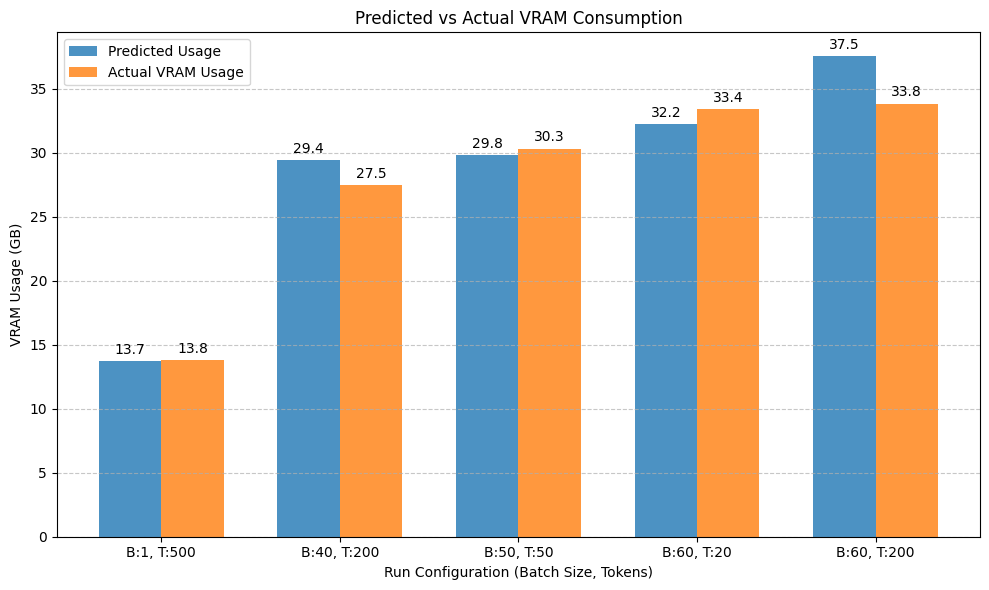

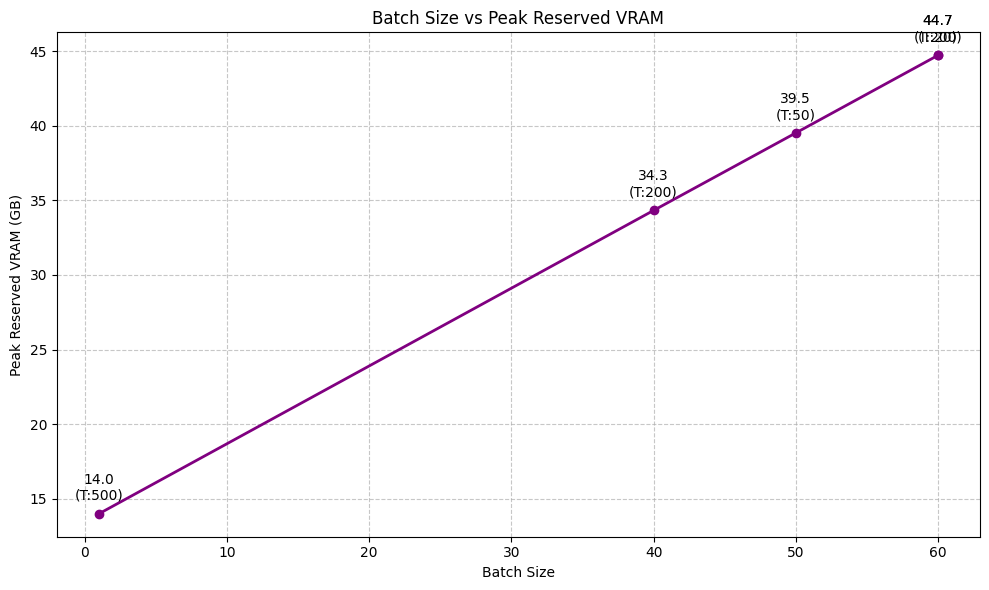

In [6]:
columns = ["Batch Size", "Tokens", "Predicted Usage", "Actual VRAM Usage", "Peak Reserved VRAM"]
df = pd.DataFrame(data, columns=columns)

df["Actual VRAM Usage"] = pd.to_numeric(df["Actual VRAM Usage"], errors='coerce')
df["Peak Reserved VRAM"] = pd.to_numeric(df["Peak Reserved VRAM"], errors='coerce')

df_success = df.dropna().copy()
df_success = df_success.sort_values(by="Batch Size")

plt.figure(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(df_success))

p1 = plt.bar(index, df_success["Predicted Usage"], bar_width, label='Predicted Usage', alpha=0.8)
p2 = plt.bar(index + bar_width, df_success["Actual VRAM Usage"], bar_width, label='Actual VRAM Usage', alpha=0.8)

plt.xlabel('Run Configuration (Batch Size, Tokens)')
plt.ylabel('VRAM Usage (GB)')
plt.title('Predicted vs Actual VRAM Consumption')
plt.xticks(index + bar_width / 2, [f"B:{b}, T:{t}" for b, t in zip(df_success["Batch Size"], df_success["Tokens"])])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.bar_label(p1, fmt='%.1f', padding=3)
plt.bar_label(p2, fmt='%.1f', padding=3)
plt.tight_layout()

df_line = df_success.sort_values(by="Batch Size")

plt.figure(figsize=(10, 6))
plt.plot(df_line["Batch Size"], df_line["Peak Reserved VRAM"], marker='o', linestyle='-', color='purple', linewidth=2)


for i, row in df_line.iterrows():
    plt.annotate(f"{row['Peak Reserved VRAM']:.1f}\n(T:{int(row['Tokens'])})", 
                 (row['Batch Size'], row['Peak Reserved VRAM']),
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center')

plt.xlabel('Batch Size')
plt.ylabel('Peak Reserved VRAM (GB)')
plt.title('Batch Size vs Peak Reserved VRAM')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

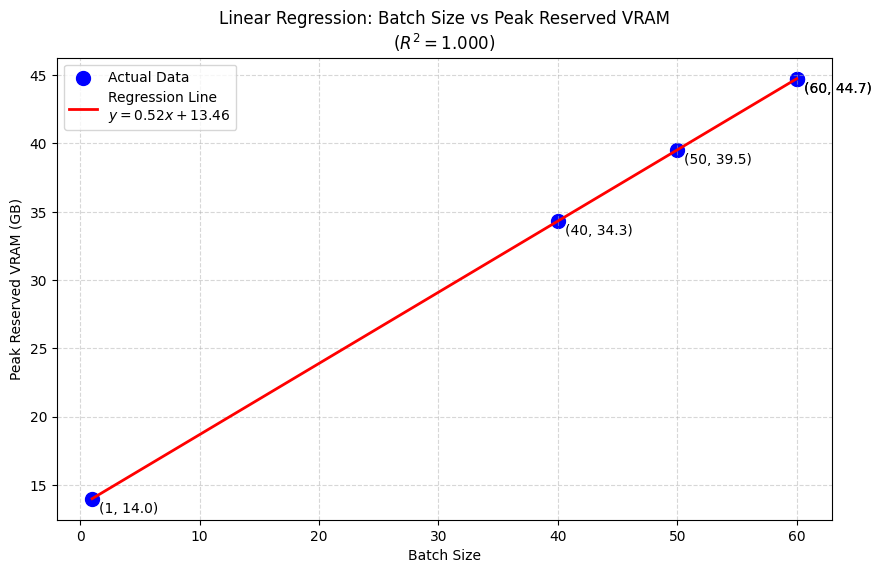

In [7]:
X = df_success[["Batch Size"]].values
y = df_success["Peak Reserved VRAM"].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

slope = model.coef_[0]
intercept = model.intercept_

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Actual Data', s=100)
plt.plot(X, y_pred, color='red', linewidth=2, label=f'Regression Line\n$y = {slope:.2f}x + {intercept:.2f}$')

for i, val in enumerate(y):
     plt.annotate(f"({X[i][0]}, {val:.1f})", (X[i][0], val), xytext=(5, -10), textcoords='offset points')

plt.xlabel('Batch Size')
plt.ylabel('Peak Reserved VRAM (GB)')
plt.title(f'Linear Regression: Batch Size vs Peak Reserved VRAM\n($R^2 = {r2:.3f}$)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
data = np.array([
    [60, 20,  44.738],
    [50, 50,  39.530],
    [1,  500, 13.980],
    [40, 200, 34.330],
    [60, 200, 44.740],
])

X = data[:, :2]
y = data[:, 2]  

model = LinearRegression()
model.fit(X, y)

intercept = model.intercept_
coef_batch = model.coef_[0]
coef_tokens = model.coef_[1]
r_squared = model.score(X, y)

print(f"Intercept (Base VRAM):  {intercept:.4f} GB")
print(f"Batch Coefficient:      {coef_batch:.4f} GB per batch")
print(f"Token Coefficient:      {coef_tokens:.8f} GB per token")
print(f"R² Score:               {r_squared:.8f}")

Intercept (Base VRAM):  13.4698 GB
Batch Coefficient:      0.5212 GB per batch
Token Coefficient:      -0.00001361 GB per token
R² Score:               0.99999964


In [9]:
def predict_vram_reserved(batch_size, num_tokens):
    vram_util, _, _=estimator.estimate(batch_size, num_tokens)
    v_ram_reserved= intercept + (coef_batch * batch_size) + (coef_tokens * num_tokens)
    return float(vram_util), float(v_ram_reserved.item())

In [11]:
vram_util, v_ram_reserved = predict_vram_reserved(20, 350)
vram_util, v_ram_reserved

(22.742006301879883, 23.88990606560865)